# 순환 신경망
## Vanilla RNN · LSTM · GRU 구조 이해 및 NumPy/PyTorch 구현

| 파트 | 내용 |
|------|------|
| **PART 1** | Vanilla RNN — 기본 구조, BPTT, 기울기 소실 문제 |
| **PART 2** | LSTM — 게이트 메커니즘, 셀 상태, 구현 및 실습 |
| **PART 3** | GRU 논문 리뷰 — 구조 분석, LSTM과 차이점 비교 |
| **PART 4** | 세 모델 정량 비교 실험 |


In [9]:
# 패키지 설치
!pip install torch matplotlib numpy scikit-learn -q

import math, random, time, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch, Circle
import matplotlib.gridspec as gridspec
warnings.filterwarnings("ignore")

# 한글 폰트
!apt-get install -y fonts-nanum > /dev/null 2>&1
import matplotlib.font_manager as fm
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 110

# 시드 고정
np.random.seed(42); random.seed(42)

print("✅ 환경 설정 완료")

import torch
print(f"   PyTorch: {torch.__version__}")
print(f"   Device : {'CUDA' if torch.cuda.is_available() else 'CPU'}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


✅ 환경 설정 완료
   PyTorch: 2.10.0+cpu
   Device : CPU


---
# PART 1. Vanilla RNN

## 1-1. 기본 구조와 수식

### 핵심 수식

$$\boxed{h_t = \tanh(W_{xh}\, x_t + W_{hh}\, h_{t-1} + b_h)}$$

$$\hat{y}_t = W_{hy}\, h_t + b_y$$

| 기호 | 의미 | 차원 |
|------|------|------|
| $x_t$ | t번째 입력 벡터 | $(I, 1)$ |
| $h_t$ | t번째 은닉 상태 | $(H, 1)$ |
| $W_{xh}$ | 입력→은닉 가중치 | $(H, I)$ |
| $W_{hh}$ | 은닉→은닉 가중치 | $(H, H)$ |
| $\hat{y}_t$ | t번째 출력 | $(O, 1)$ |

### 구조적 특징
- **파라미터 공유**: 모든 시간 스텝에서 동일한 $W_{xh}, W_{hh}$ 사용
- **은닉 상태 $h_t$**: 과거 정보를 압축한 "기억" 역할
- **단방향**: 과거 → 현재 방향으로만 정보 흐름


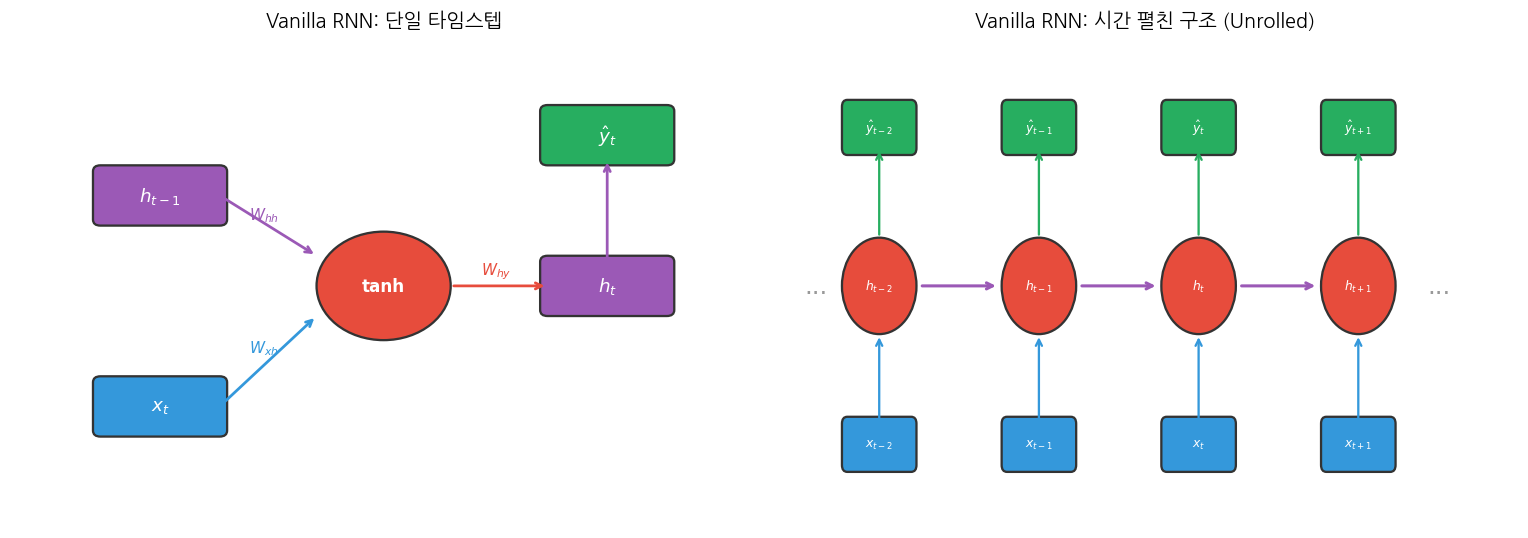

In [10]:
# ── Vanilla RNN 구조 시각화 ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# [왼쪽] 단일 스텝 구조
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 8); ax.axis('off')
ax.set_title("Vanilla RNN: 단일 타임스텝", fontproperties=font_prop, fontsize=13, pad=12)

def draw_node(ax, cx, cy, r, color, label, fontsize=11):
    circle = plt.Circle((cx, cy), r, color=color, ec='#333', lw=1.5, zorder=3)
    ax.add_patch(circle)
    ax.text(cx, cy, label, ha='center', va='center',
            fontsize=fontsize, fontweight='bold', color='white', zorder=4)

def draw_box(ax, x, y, w, h, color, label, fontsize=10):
    rect = FancyBboxPatch((x-w/2, y-h/2), w, h,
                           boxstyle="round,pad=0.1", fc=color, ec='#333', lw=1.5, zorder=3)
    ax.add_patch(rect)
    ax.text(x, y, label, ha='center', va='center',
            fontsize=fontsize, fontweight='bold', color='white', zorder=4)

def arrow(ax, x1,y1,x2,y2,color='#555',lw=1.8):
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=lw))

# x_t 입력
draw_box(ax, 2, 2, 1.6, 0.8, '#3498db', '$x_t$', 12)
# h_{t-1} 입력
draw_box(ax, 2, 5.5, 1.6, 0.8, '#9b59b6', '$h_{t-1}$', 12)
# tanh 노드
draw_node(ax, 5, 4, 0.9, '#e74c3c', 'tanh')
# h_t 출력
draw_box(ax, 8, 4, 1.6, 0.8, '#9b59b6', '$h_t$', 12)
# y_t 출력
draw_box(ax, 8, 6.5, 1.6, 0.8, '#27ae60', '$\hat{y}_t$', 12)

arrow(ax, 2.8, 2, 4.1, 3.5, '#3498db')
arrow(ax, 2.8, 5.5, 4.1, 4.5, '#9b59b6')
arrow(ax, 5.9, 4, 7.2, 4, '#e74c3c')
arrow(ax, 8, 4.4, 8, 6.1, '#9b59b6')

ax.text(3.2, 2.9, '$W_{xh}$', fontsize=10, color='#3498db', style='italic')
ax.text(3.2, 5.1, '$W_{hh}$', fontsize=10, color='#9b59b6', style='italic')
ax.text(6.3, 4.2, '$W_{hy}$', fontsize=10, color='#e74c3c', style='italic')

# [오른쪽] 시간 펼친 구조 (unrolled)
ax2 = axes[1]
ax2.set_xlim(0, 14); ax2.set_ylim(0, 7); ax2.axis('off')
ax2.set_title("Vanilla RNN: 시간 펼친 구조 (Unrolled)", fontproperties=font_prop, fontsize=13, pad=12)

xs = [2, 5, 8, 11]
labels_t = ['$t-2$', '$t-1$', '$t$', '$t+1$']
colors_h = ['#9b59b6'] * 4

for i, (x, lab) in enumerate(zip(xs, labels_t)):
    # h 노드
    draw_node(ax2, x, 3.5, 0.7, '#e74c3c', f'$h_{{{lab[1:-1]}}}$', 8)
    # x 입력
    draw_box(ax2, x, 1.2, 1.2, 0.6, '#3498db', f'$x_{{{lab[1:-1]}}}$', 8)
    # y 출력
    draw_box(ax2, x, 5.8, 1.2, 0.6, '#27ae60', f'$\hat{{y}}_{{{lab[1:-1]}}}$', 8)
    ax2.annotate('', xy=(x, 2.8), xytext=(x, 1.5),
                 arrowprops=dict(arrowstyle='->', color='#3498db', lw=1.5))
    ax2.annotate('', xy=(x, 5.5), xytext=(x, 4.2),
                 arrowprops=dict(arrowstyle='->', color='#27ae60', lw=1.5))

# 수평 화살표 (h → h)
for i in range(len(xs)-1):
    ax2.annotate('', xy=(xs[i+1]-0.75, 3.5), xytext=(xs[i]+0.75, 3.5),
                 arrowprops=dict(arrowstyle='->', color='#9b59b6', lw=2))

ax2.text(0.6, 3.5, '...', fontsize=16, va='center', color='#999')
ax2.text(12.3, 3.5, '...', fontsize=16, va='center', color='#999')

plt.tight_layout(); plt.show()


## 1-2. Vanilla RNN NumPy 구현

### BPTT (Backpropagation Through Time)

시간 축을 펼쳐서 역전파:

$$\frac{\partial L}{\partial W_{hh}} = \sum_{t=1}^{T} \frac{\partial L_t}{\partial h_t} \cdot \frac{\partial h_t}{\partial W_{hh}}$$

$$\frac{\partial h_t}{\partial h_k} = \prod_{j=k+1}^{t} \frac{\partial h_j}{\partial h_{j-1}} = \prod_{j=k+1}^{t} W_{hh}^\top \cdot \text{diag}(1 - h_j^2)$$

**기울기 소실 문제**: $\|W_{hh}\| < 1$이면 $T$가 클수록 기울기 → 0


In [11]:
def sigmoid(x): return 1.0 / (1.0 + np.exp(-np.clip(x, -30, 30)))
def dsigmoid(y): return y * (1.0 - y)
def dtanh(y): return 1.0 - y**2


class VanillaRNNNumpy:
    """
    Vanilla RNN — NumPy 완전 구현
      h_t = tanh(Wxh @ x_t + Whh @ h_{t-1} + bh)
      y_t = Why @ h_t + by
    """
    def __init__(self, input_size, hidden_size, output_size, lr=0.01):
        self.I = input_size
        self.H = hidden_size
        self.O = output_size
        self.lr = lr
        # Xavier 초기화
        self.Wxh = np.random.randn(hidden_size, input_size)  * np.sqrt(2/(input_size+hidden_size))
        self.Whh = np.random.randn(hidden_size, hidden_size) * np.sqrt(2/(hidden_size+hidden_size))
        self.Why = np.random.randn(output_size, hidden_size) * np.sqrt(2/(hidden_size+output_size))
        self.bh  = np.zeros((hidden_size, 1))
        self.by  = np.zeros((output_size, 1))

    def forward(self, xs, h0=None):
        """
        xs: list of (I,1) arrays  길이 T
        반환: hs (은닉 상태 리스트), ys (출력 리스트), hs_raw (pre-tanh)
        """
        T = len(xs)
        h = h0 if h0 is not None else np.zeros((self.H, 1))
        hs, ys, hs_raw = [h], [], []
        for x in xs:
            raw = self.Wxh @ x + self.Whh @ hs[-1] + self.bh
            h   = np.tanh(raw)
            y   = self.Why @ h + self.by
            hs.append(h);  ys.append(y);  hs_raw.append(raw)
        return hs, ys, hs_raw

    def bptt(self, xs, ys_true, h0=None, truncate=None):
        """
        BPTT (Backpropagation Through Time)
        truncate: None이면 전체, 정수면 Truncated BPTT
        """
        T = len(xs)
        hs, ys_pred, hs_raw = self.forward(xs, h0)

        dWxh = np.zeros_like(self.Wxh)
        dWhh = np.zeros_like(self.Whh)
        dWhy = np.zeros_like(self.Why)
        dbh  = np.zeros_like(self.bh)
        dby  = np.zeros_like(self.by)
        dh_next = np.zeros((self.H, 1))

        total_loss = 0.0
        for t in reversed(range(T)):
            # MSE 손실
            dy = ys_pred[t] - ys_true[t]
            total_loss += float(np.sum(dy**2))
            dWhy += dy @ hs[t+1].T
            dby  += dy
            dh    = self.Why.T @ dy + dh_next
            dh_raw = dh * dtanh(hs[t+1])
            dbh  += dh_raw
            dWxh += dh_raw @ xs[t].T
            dWhh += dh_raw @ hs[t].T
            dh_next = self.Whh.T @ dh_raw
            # Truncated BPTT
            if truncate and (T - t) >= truncate:
                break

        # Gradient clipping (norm)
        for grad in [dWxh, dWhh, dWhy, dbh, dby]:
            np.clip(grad, -5, 5, out=grad)

        # SGD 업데이트
        self.Wxh -= self.lr * dWxh
        self.Whh -= self.lr * dWhh
        self.Why -= self.lr * dWhy
        self.bh  -= self.lr * dbh
        self.by  -= self.lr * dby

        return total_loss / T

    def count_params(self):
        return (self.Wxh.size + self.Whh.size + self.Why.size
                + self.bh.size + self.by.size)


# ── 파라미터 수 확인 ──
I, H, O = 1, 16, 1
rnn = VanillaRNNNumpy(I, H, O, lr=0.01)
print(f"Vanilla RNN 파라미터 수: {rnn.count_params():,}개")
print(f"  Wxh: {rnn.Wxh.shape}  Whh: {rnn.Whh.shape}  Why: {rnn.Why.shape}")


Vanilla RNN 파라미터 수: 305개
  Wxh: (16, 1)  Whh: (16, 16)  Why: (1, 16)


최종 훈련 손실: 0.000974


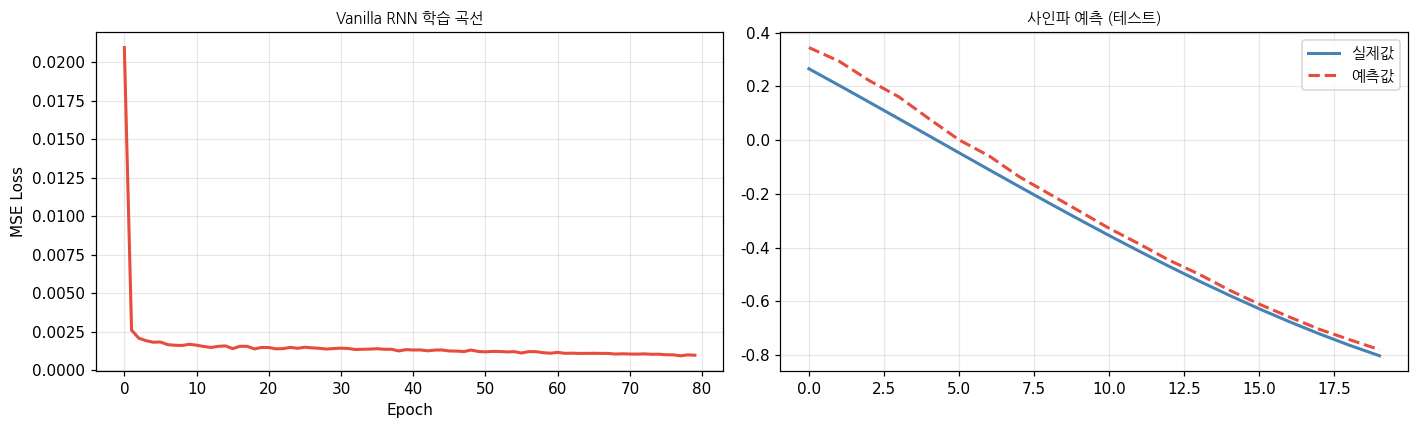

In [12]:
# ── 사인파 예측 실습 ──
T_total = 200
t_axis  = np.linspace(0, 4*np.pi, T_total)
signal  = np.sin(t_axis)

# 시퀀스 슬라이딩 윈도우 생성
SEQ_LEN = 20
def make_sequences(data, seq_len):
    X, Y = [], []
    for i in range(len(data) - seq_len):
        X.append([np.array([[v]]) for v in data[i:i+seq_len]])
        Y.append([np.array([[v]]) for v in data[i+1:i+seq_len+1]])
    return X, Y

X_all, Y_all = make_sequences(signal, SEQ_LEN)
split = int(len(X_all) * 0.8)
X_tr, Y_tr = X_all[:split], Y_all[:split]
X_te, Y_te = X_all[split:], Y_all[split:]

# 훈련
rnn_sin = VanillaRNNNumpy(1, 32, 1, lr=0.005)
train_losses = []
EPOCHS = 80

for ep in range(EPOCHS):
    ep_loss = 0
    indices = list(range(len(X_tr))); random.shuffle(indices)
    for idx in indices:
        loss = rnn_sin.bptt(X_tr[idx], Y_tr[idx])
        ep_loss += loss
    train_losses.append(ep_loss / len(X_tr))

print(f"최종 훈련 손실: {train_losses[-1]:.6f}")

# 예측
def predict_seq(model, xs):
    hs, ys, _ = model.forward(xs)
    return [float(y) for y in ys]

pred = predict_seq(rnn_sin, X_te[0])
true = [float(y) for y in Y_te[0]]

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(train_losses, color='#e74c3c', lw=2)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Vanilla RNN 학습 곡선", fontproperties=font_prop)
axes[0].grid(alpha=0.3)

axes[1].plot(true, label='실제값', color='steelblue', lw=2)
axes[1].plot(pred, label='예측값', color='#e74c3c', lw=2, ls='--')
axes[1].set_title(f"사인파 예측 (테스트)", fontproperties=font_prop)
axes[1].legend(prop=font_prop); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()


## 1-3. 기울기 소실(Vanishing Gradient) 문제

**핵심 원인**: BPTT에서 $t$에서 $k$로 역전파 시

$$\frac{\partial h_t}{\partial h_k} = \prod_{j=k+1}^{t} W_{hh}^\top \cdot \text{diag}(1 - h_j^2)$$

- $\|W_{hh}\| < 1$ → **기울기 소실** (긴 의존성 학습 불가)
- $\|W_{hh}\| > 1$ → **기울기 폭발** (학습 발산)

→ LSTM / GRU는 이 문제를 **게이트 메커니즘**으로 해결


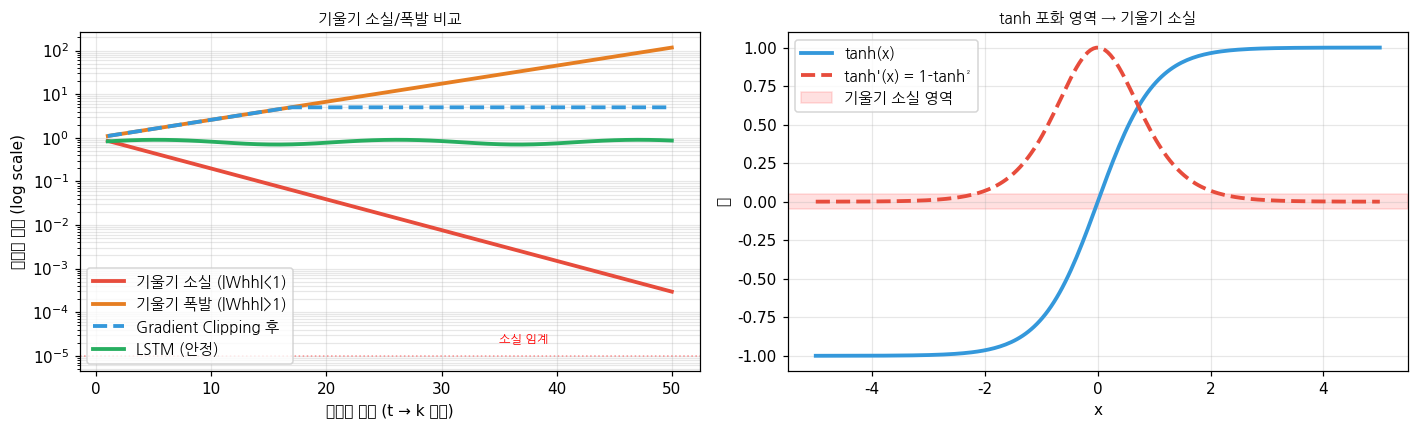

■ 핵심: tanh 포화 + Whh 반복 곱 → 장기 의존성 학습 실패


In [13]:
# ── 기울기 소실 시각화 ──
steps = np.arange(1, 51)

# 시나리오별 기울기 크기 시뮬레이션
grad_vanish  = 0.85 ** steps          # Whh 스펙트럼 < 1
grad_explode = 1.10 ** steps          # Whh 스펙트럼 > 1
grad_clip    = np.minimum(grad_explode, 5.0)  # Gradient clipping 적용
grad_lstm    = np.ones(len(steps)) * 0.8 + 0.1*np.sin(steps*0.3)  # LSTM (gate로 안정)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.semilogy(steps, grad_vanish,  lw=2.5, color='#e74c3c',   label='기울기 소실 (|Whh|<1)')
ax.semilogy(steps, grad_explode, lw=2.5, color='#e67e22',   label='기울기 폭발 (|Whh|>1)')
ax.semilogy(steps, grad_clip,    lw=2.5, color='#3498db',   ls='--', label='Gradient Clipping 후')
ax.semilogy(steps, grad_lstm,    lw=2.5, color='#27ae60',   label='LSTM (안정)')
ax.set_xlabel("역전파 스텝 (t → k 거리)"); ax.set_ylabel("기울기 크기 (log scale)")
ax.set_title("기울기 소실/폭발 비교", fontproperties=font_prop)
ax.legend(prop=font_prop, fontsize=9); ax.grid(alpha=0.3, which='both')
ax.axhline(1e-5, color='red', ls=':', alpha=0.4, lw=1)
ax.text(35, 2e-5, '소실 임계', color='red', fontsize=8, fontproperties=font_prop)

# 활성화 함수 포화(saturation) 시각화
ax2 = axes[1]
x_ = np.linspace(-5, 5, 200)
tanh_v = np.tanh(x_)
dtanh_v = 1 - tanh_v**2
ax2.plot(x_, tanh_v,  lw=2.5, color='#3498db', label='tanh(x)')
ax2.plot(x_, dtanh_v, lw=2.5, color='#e74c3c', ls='--', label="tanh'(x) = 1-tanh²")
ax2.axhspan(-0.05, 0.05, alpha=0.12, color='red', label='기울기 소실 영역')
ax2.set_title("tanh 포화 영역 → 기울기 소실", fontproperties=font_prop)
ax2.legend(prop=font_prop); ax2.grid(alpha=0.3)
ax2.set_xlabel("x"); ax2.set_ylabel("값")

plt.tight_layout(); plt.show()
print("■ 핵심: tanh 포화 + Whh 반복 곱 → 장기 의존성 학습 실패")


---
# PART 2. LSTM (Long Short-Term Memory)

## 2-1. 구조와 게이트 메커니즘

> Hochreiter & Schmidhuber (1997) — *Long Short-Term Memory*

### 핵심 아이디어: 셀 상태(Cell State) $c_t$

RNN이 하나의 은닉 상태($h_t$)만 갖는 것과 달리, LSTM은 두 가지를 관리합니다.

| 상태 | 역할 | 특징 |
|------|------|------|
| $c_t$ (셀 상태) | 장기 기억 (Long-term memory) | 덧셈 연산 → 기울기 보존 |
| $h_t$ (은닉 상태) | 단기 기억 (Short-term memory) | 현재 출력에 사용 |

### 4개 게이트 수식

$$\text{Forget Gate:}\quad f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$
$$\text{Input Gate:}\quad i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$$
$$\text{Cell Gate:}\quad \tilde{c}_t = \tanh(W_c \cdot [h_{t-1}, x_t] + b_c)$$
$$\text{Output Gate:}\quad o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$$

### 상태 업데이트

$$\boxed{c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t}$$
$$\boxed{h_t = o_t \odot \tanh(c_t)}$$

**CEC (Constant Error Carousel)**: $c_t$는 덧셈으로 업데이트 → 역전파 시 기울기가 그대로 통과


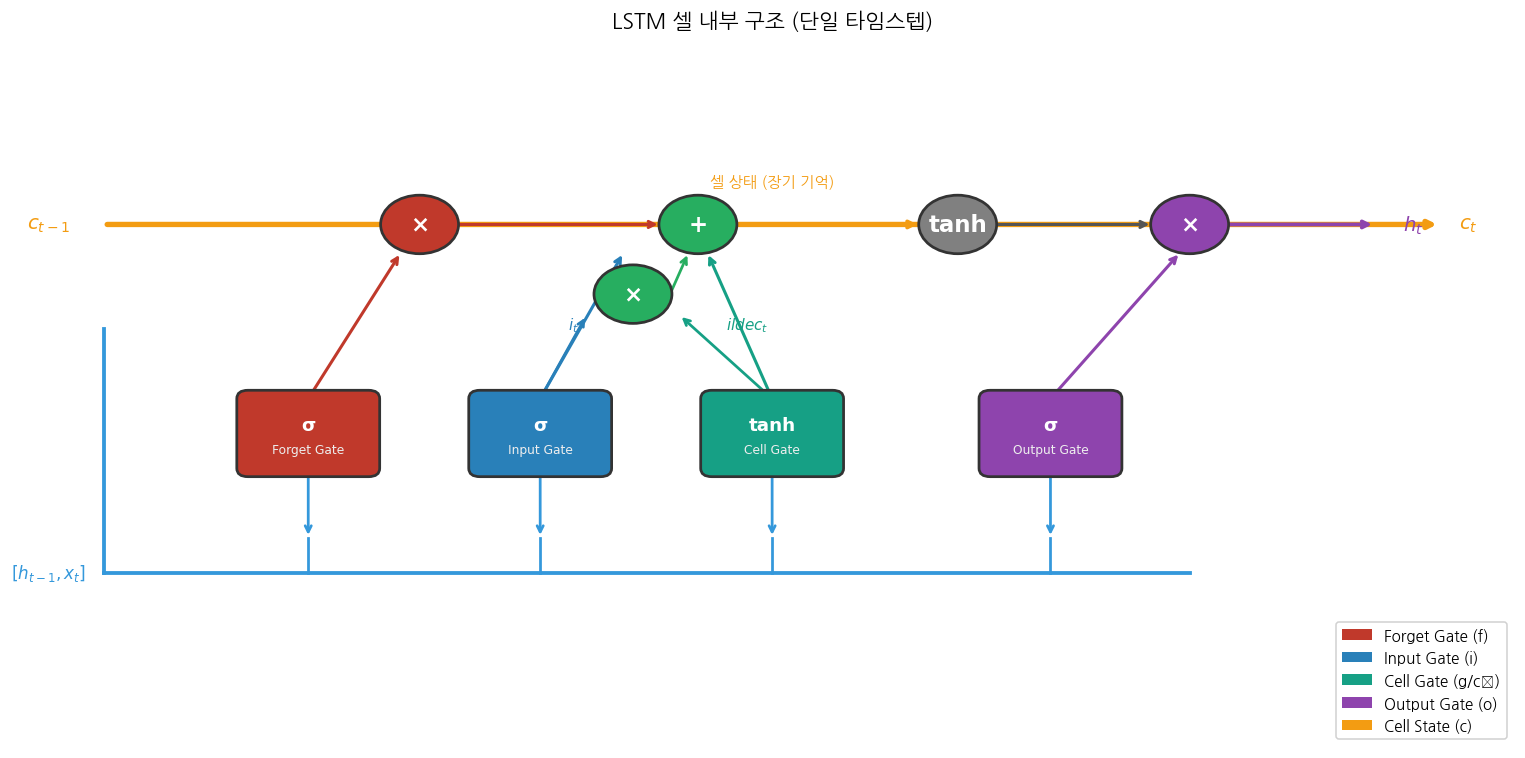

In [14]:
# ── LSTM 구조 시각화 ──
fig, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(0, 16); ax.set_ylim(0, 10); ax.axis('off')
ax.set_title("LSTM 셀 내부 구조 (단일 타임스텝)", fontproperties=font_prop, fontsize=14, pad=15)

# ── 헬퍼 함수 ──
def gate_box(ax, cx, cy, color, label, sublabel=""):
    r = FancyBboxPatch((cx-0.65, cy-0.5), 1.3, 1.0,
                        boxstyle="round,pad=0.12", fc=color, ec='#333', lw=1.8, zorder=4)
    ax.add_patch(r)
    ax.text(cx, cy+0.12, label,    ha='center', va='center', fontsize=12, fontweight='bold', color='white', zorder=5)
    ax.text(cx, cy-0.23, sublabel, ha='center', va='center', fontsize=8,  color='#eee',     zorder=5)

def op_circle(ax, cx, cy, color, label):
    c = plt.Circle((cx,cy), 0.42, color=color, ec='#333', lw=1.8, zorder=4)
    ax.add_patch(c)
    ax.text(cx, cy, label, ha='center', va='center', fontsize=15, fontweight='bold', color='white', zorder=5)

def arr(ax, x1,y1,x2,y2, color='#555', lw=1.8, style='-'):
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=lw, linestyle=style))

# ── 상단 셀 상태 라인 (C_t-1 → C_t) ──
ax.annotate('', xy=(15.2, 7.5), xytext=(0.8, 7.5),
            arrowprops=dict(arrowstyle='->', color='#f39c12', lw=3.5))
ax.text(0.2, 7.5, '$c_{t-1}$', ha='center', va='center', fontsize=13, color='#f39c12', fontweight='bold')
ax.text(15.5, 7.5, '$c_t$',   ha='center', va='center', fontsize=13, color='#f39c12', fontweight='bold')
ax.text(8, 8.05, '셀 상태 (장기 기억)', ha='center', fontsize=10, color='#f39c12',
        fontproperties=font_prop, style='italic')

# ── 게이트들 ──
gate_colors = ['#c0392b','#2980b9','#16a085','#8e44ad']
gate_xs = [3, 5.5, 8, 11]
gate_labels = ['σ','σ','tanh','σ']
gate_names  = ['Forget Gate','Input Gate','Cell Gate','Output Gate']

for x, lbl, nm, col in zip(gate_xs, gate_labels, gate_names, gate_colors):
    gate_box(ax, x, 4.5, col, lbl, nm)

# ── 연산 노드 ──
op_circle(ax, 4.2, 7.5, '#c0392b', '×')  # forget × C_{t-1}
op_circle(ax, 7.2, 7.5, '#27ae60', '+')  # add
op_circle(ax, 10, 7.5, 'gray', 'tanh')  # tanh(C_t)
op_circle(ax, 12.5, 7.5, '#8e44ad', '×')  # output × tanh

# ── x_t, h_{t-1} 입력 라인 ──
ax.plot([0.8, 0.8], [2.5, 6], color='#3498db', lw=2.5, zorder=2)
ax.plot([0.8, 12.5], [2.5, 2.5], color='#3498db', lw=2.5, zorder=2)
ax.text(0.2, 2.5, '$[h_{t-1}, x_t]$', ha='center', va='center',
        fontsize=11, color='#3498db', fontweight='bold')

for gx in gate_xs:
    arr(ax, gx, 4.0, gx, 3.0, '#3498db')
    ax.plot([gx, gx], [3.0, 2.5], color='#3498db', lw=1.8, zorder=2)

# ── 게이트 → 연산 ──
arr(ax, 3, 5.0, 4.0, 7.1,  '#c0392b', 2)    # forget → ×
arr(ax, 5.5, 5.0, 6.4, 7.1, '#2980b9', 2)   # input → +(via ×이 아님)
arr(ax, 8, 5.0, 7.3, 7.1,  '#16a085', 2)    # cell → +
arr(ax, 11, 5.0, 12.4, 7.1,'#8e44ad', 2)    # output → ×

# × (forget)로 들어오는 C_{t-1} 라인 이미 그려짐
arr(ax, 4.6, 7.5, 6.8, 7.5, '#c0392b', 2)   # × → +
arr(ax, 7.6, 7.5, 9.6, 7.5, '#f39c12', 2.5) # + → tanh(Ct)
arr(ax, 10.4, 7.5, 12.1, 7.5,'#555', 2)     # tanh → ×(output)

# h_t 출력
arr(ax, 12.9, 7.5, 14.5, 7.5, '#8e44ad', 2.5)
ax.text(14.8, 7.5, '$h_t$', fontsize=13, color='#8e44ad', fontweight='bold', va='center')

# i_t × g_t 따로 계산
arr(ax, 5.5, 5.0, 6.0, 6.2, '#2980b9', 1.8)
arr(ax, 8, 5.0, 7.0, 6.2, '#16a085', 1.8)
op_circle(ax, 6.5, 6.5, '#27ae60', '×')
arr(ax, 6.9, 6.5, 7.1, 7.1, '#27ae60', 1.8)
ax.text(5.8, 6.0, '$i_t$', fontsize=10, color='#2980b9', style='italic')
ax.text(7.5, 6.0, '$\tilde{c}_t$', fontsize=10, color='#16a085', style='italic')

# 범례
from matplotlib.patches import Patch
legend_els = [
    Patch(fc='#c0392b', label='Forget Gate (f)'),
    Patch(fc='#2980b9', label='Input Gate (i)'),
    Patch(fc='#16a085', label='Cell Gate (g/c̃)'),
    Patch(fc='#8e44ad', label='Output Gate (o)'),
    Patch(fc='#f39c12', label='Cell State (c)'),
]
ax.legend(handles=legend_els, loc='lower right', fontsize=9,
          prop=font_prop, framealpha=0.9)

plt.tight_layout(); plt.show()


## 2-2. LSTM NumPy 완전 구현

### 행렬 합산 최적화 (4-gate concatenation)

4개 게이트를 개별 행렬로 구현하는 대신, **하나의 큰 행렬로 합산**하면 연산 효율이 높아집니다:

$$\begin{pmatrix} f_t \\ i_t \\ \tilde{c}_t \\ o_t \end{pmatrix} = \begin{pmatrix} \sigma \\ \sigma \\ \tanh \\ \sigma \end{pmatrix} \left( W \begin{pmatrix} h_{t-1} \\ x_t \end{pmatrix} + b \right), \quad W \in \mathbb{R}^{4H \times (H+I)}$$


In [15]:
class LSTMNumpy:
    """
    LSTM — NumPy 완전 구현 (4-gate 합산 행렬)

    h_t, c_t = LSTM(x_t, h_{t-1}, c_{t-1})
    y_t = Why @ h_t + by

    파라미터:
      W   : (4H, I+H)   — [Wf | Wi | Wg | Wo] 합산
      b   : (4H, 1)
      Why : (O, H)
      by  : (O, 1)
    """
    def __init__(self, input_size, hidden_size, output_size, lr=0.01):
        self.I = input_size
        self.H = hidden_size
        self.O = output_size
        self.lr = lr
        D = input_size + hidden_size
        # 4 게이트 합산 행렬 (Xavier)
        self.W  = np.random.randn(4*hidden_size, D) * np.sqrt(2/D)
        self.b  = np.zeros((4*hidden_size, 1))
        # Forget gate bias를 1로 초기화 → 초기에 기억을 잘 유지
        self.b[0:hidden_size] = 1.0
        self.Why = np.random.randn(output_size, hidden_size) * np.sqrt(2/hidden_size)
        self.by  = np.zeros((output_size, 1))

    def forward(self, xs, h0=None, c0=None):
        T = len(xs)
        H = self.H
        h = h0 if h0 is not None else np.zeros((H, 1))
        c = c0 if c0 is not None else np.zeros((H, 1))
        cache = []                    # (x, h_prev, c_prev, gates, h, c)
        hs, cs, ys = [h], [c], []

        for x in xs:
            combined = np.vstack([h, x])           # (I+H, 1)
            raw = self.W @ combined + self.b        # (4H, 1)
            f = sigmoid(raw[0*H:1*H])              # Forget gate
            i = sigmoid(raw[1*H:2*H])              # Input gate
            g = np.tanh(raw[2*H:3*H])              # Cell gate
            o = sigmoid(raw[3*H:4*H])              # Output gate
            c_new = f * c + i * g                  # 셀 상태 업데이트
            h_new = o * np.tanh(c_new)             # 은닉 상태
            y     = self.Why @ h_new + self.by
            cache.append((x, h, c, f, i, g, o, raw, combined))
            h, c = h_new, c_new
            hs.append(h); cs.append(c); ys.append(y)

        return hs, cs, ys, cache

    def bptt(self, xs, ys_true, h0=None, c0=None):
        T = len(xs)
        H = self.H
        hs, cs, ys_pred, cache = self.forward(xs, h0, c0)

        dW   = np.zeros_like(self.W)
        db   = np.zeros_like(self.b)
        dWhy = np.zeros_like(self.Why)
        dby  = np.zeros_like(self.by)
        dh_next = np.zeros((H, 1))
        dc_next = np.zeros((H, 1))

        total_loss = 0.0
        for t in reversed(range(T)):
            x, h_prev, c_prev, f, i, g, o, raw, combined = cache[t]
            h_curr = hs[t+1]
            c_curr = cs[t+1]

            dy = ys_pred[t] - ys_true[t]
            total_loss += float(np.sum(dy**2))
            dWhy += dy @ h_curr.T
            dby  += dy

            dh = self.Why.T @ dy + dh_next  # 출력 + 다음 타임스텝 기울기
            dc = dh * o * dtanh(np.tanh(c_curr)) + dc_next  # CEC 통과

            # 게이트 기울기
            do_raw = dh * np.tanh(c_curr) * dsigmoid(o)
            df_raw = dc * c_prev          * dsigmoid(f)
            di_raw = dc * g               * dsigmoid(i)
            dg_raw = dc * i               * dtanh(g)

            d_raw = np.vstack([df_raw, di_raw, dg_raw, do_raw])
            dW   += d_raw @ combined.T
            db   += d_raw
            d_combined = self.W.T @ d_raw
            dh_next = d_combined[:H]      # h_prev 부분
            dc_next = dc * f              # c_prev 부분 (CEC)

        # Gradient clipping
        for grad in [dW, db, dWhy, dby]:
            np.clip(grad, -5, 5, out=grad)

        self.W   -= self.lr * dW
        self.b   -= self.lr * db
        self.Why -= self.lr * dWhy
        self.by  -= self.lr * dby

        return total_loss / T

    def count_params(self):
        return self.W.size + self.b.size + self.Why.size + self.by.size


I, H, O = 1, 16, 1
lstm = LSTMNumpy(I, H, O)
print(f"LSTM 파라미터 수: {lstm.count_params():,}개")
print(f"  W: {lstm.W.shape}  (4×H, I+H) — 4게이트 합산")
print(f"  b: {lstm.b.shape}  Forget gate bias 초기값=1 (기억 유지)")

# 포워드 테스트
xs_test = [np.array([[v]]) for v in [0.1, 0.5, -0.3, 0.8, 0.2]]
hs_, cs_, ys_, _ = lstm.forward(xs_test)
print(f"\n포워드 테스트 완료: h shape={hs_[-1].shape}, c shape={cs_[-1].shape}")


LSTM 파라미터 수: 1,169개
  W: (64, 17)  (4×H, I+H) — 4게이트 합산
  b: (64, 1)  Forget gate bias 초기값=1 (기억 유지)

포워드 테스트 완료: h shape=(16, 1), c shape=(16, 1)


In [27]:
def predict_seq(model, xs):
    if isinstance(model, LSTMNumpy):
        hs, cs, ys, cache = model.forward(xs)
    elif isinstance(model, VanillaRNNNumpy):
        hs, ys, hs_raw = model.forward(xs)
    elif isinstance(model, GRUNumpy): # GRUNumpy 모델 추가
        hs, ys, cache = model.forward(xs)
    else:
        raise TypeError("Unsupported model type for predict_seq")
    return [float(y) for y in ys]

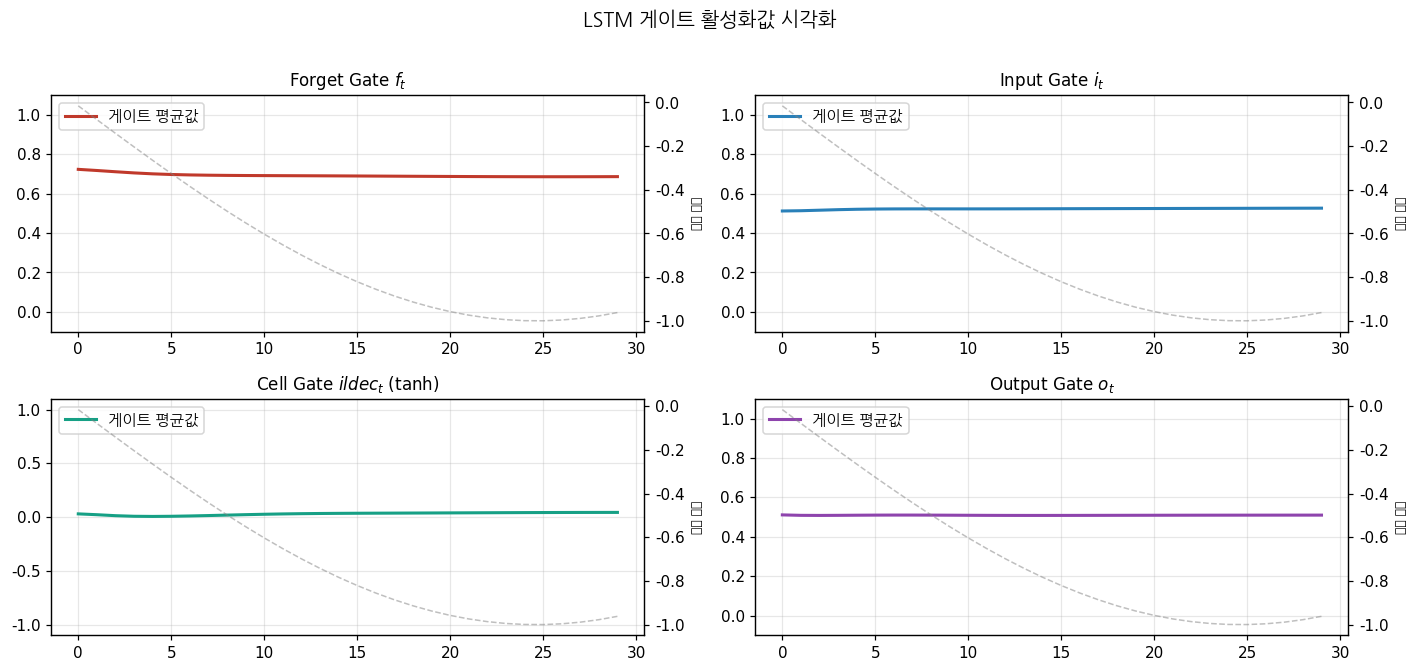

In [19]:
# ── 게이트 활성화값 시각화 ──
sample_xs = [np.array([[v]]) for v in signal[50:80]]
_, _, _, lstm_cache = lstm_sin.forward(sample_xs)

f_vals = np.array([float(c[3].mean()) for c in lstm_cache])  # forget
i_vals = np.array([float(c[4].mean()) for c in lstm_cache])  # input
g_vals = np.array([float(c[5].mean()) for c in lstm_cache])  # cell
o_vals = np.array([float(c[6].mean()) for c in lstm_cache])  # output

fig, axes = plt.subplots(2, 2, figsize=(13, 6))
gate_data = [(f_vals,'Forget Gate $f_t$','#c0392b'),
             (i_vals,'Input Gate $i_t$','#2980b9'),
             (g_vals,'Cell Gate $\tilde{c}_t$ (tanh)','#16a085'),
             (o_vals,'Output Gate $o_t$','#8e44ad')]

input_signal = signal[50:80]

for ax, (vals, title, color) in zip(axes.flat, gate_data):
    ax.plot(vals, color=color, lw=2, label='게이트 평균값')
    ax2_ = ax.twinx()
    ax2_.plot(input_signal, color='gray', lw=1, alpha=0.5, ls='--', label='입력 신호')
    ax2_.set_ylabel("입력 신호", fontsize=8)
    ax.set_title(title, fontsize=11)
    ax.set_ylim(-0.1, 1.1) if 'tanh' not in title else ax.set_ylim(-1.1, 1.1)
    ax.grid(alpha=0.3); ax.legend(prop=font_prop, fontsize=8, loc='upper left')

plt.suptitle("LSTM 게이트 활성화값 시각화", fontproperties=font_prop, fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


## 2-3. PyTorch LSTM 구현

### 문자 언어 모델 (Character-Level Language Model)


In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# ── 데이터 준비 ──
text = (
    "deep learning is a subset of machine learning "
    "neural networks have multiple layers "
    "lstm stands for long short term memory "
    "gru stands for gated recurrent unit "
    "recurrent neural networks process sequences "
    "attention mechanism improves performance "
    "transformer architecture uses self attention "
)
chars = sorted(set(text))
char2idx = {c: i for i, c in enumerate(chars)}
idx2char = {i: c for c, i in char2idx.items()}
V = len(chars)

def encode(s): return [char2idx[c] for c in s]
def decode(ids): return ''.join(idx2char[i] for i in ids)

print(f"어휘 크기: {V}개 문자")
print(f"텍스트 길이: {len(text)}자")
print(f"어휘: {''.join(chars)}")

SEQ_LEN = 25

# ── PyTorch LSTM 모델 ──
class CharLSTM(nn.Module):
    """문자 단위 LSTM 언어 모델"""
    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers=2, dropout=0.3):
        super().__init__()
        self.embed   = nn.Embedding(vocab_size, embed_dim)
        self.lstm    = nn.LSTM(embed_dim, hidden_size, num_layers,
                               batch_first=True, dropout=dropout if num_layers>1 else 0)
        self.fc      = nn.Linear(hidden_size, vocab_size)
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

    def forward(self, x, hidden=None):
        emb = self.embed(x)                  # (B, T, E)
        out, hidden = self.lstm(emb, hidden)  # (B, T, H)
        logits = self.fc(out)                 # (B, T, V)
        return logits, hidden

    def init_hidden(self, batch_size, device):
        h = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)
        c = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)
        return (h, c)

    def generate(self, seed, length=80, temperature=0.8, device='cpu'):
        self.eval()
        ids = encode(seed)
        x   = torch.LongTensor([ids]).to(device)
        hidden = self.init_hidden(1, device)
        result = seed
        with torch.no_grad():
            for _ in range(length):
                logits, hidden = self(x, hidden)
                logits = logits[:, -1, :] / temperature
                probs  = F.softmax(logits, dim=-1)
                nxt    = torch.multinomial(probs, 1).item()
                result += idx2char[nxt]
                x = torch.LongTensor([[nxt]]).to(device)
        return result

model = CharLSTM(V, embed_dim=32, hidden_size=128, num_layers=2, dropout=0.3).to(device)
print(f"\n모델 파라미터: {sum(p.numel() for p in model.parameters()):,}개")


어휘 크기: 24개 문자
텍스트 길이: 288자
어휘:  abcdefghiklmnopqrstuvwy

모델 파라미터: 218,904개


  Epoch  50/200 | loss=0.3195
  Epoch 100/200 | loss=0.0686
  Epoch 150/200 | loss=0.0431


  Epoch 200/200 | loss=0.0382


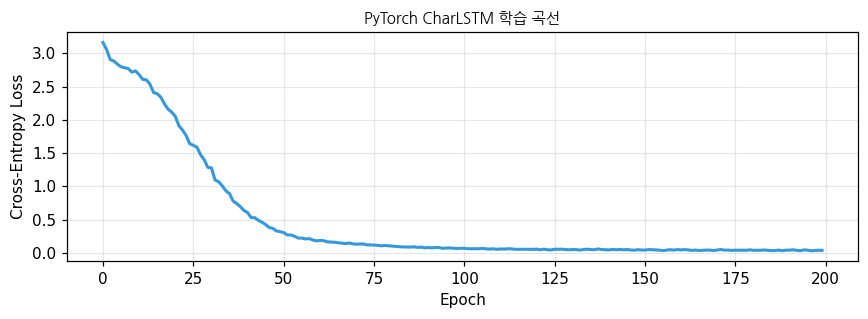


■ LSTM 텍스트 생성:
  seed='deep' (T=0.6): deep learning is a subset of machine learning neural networks pr
  seed='lstm' (T=0.8): lstm seltm stands for long short term memory gru stands for gate
  seed='neural' (T=1.0): neural networks process sequences attention mechanism improves per


In [21]:
# ── 훈련 ──
optimizer = optim.Adam(model.parameters(), lr=3e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.7)
criterion = nn.CrossEntropyLoss()

# 시퀀스 배치 생성
def make_batches(text, seq_len, batch_size=32):
    ids = encode(text)
    batches = []
    for i in range(0, len(ids)-seq_len-1, seq_len//2):
        x = ids[i:i+seq_len]
        y = ids[i+1:i+seq_len+1]
        if len(x) == seq_len:
            batches.append((x, y))
    random.shuffle(batches)
    for i in range(0, len(batches), batch_size):
        chunk = batches[i:i+batch_size]
        xs = torch.LongTensor([c[0] for c in chunk]).to(device)
        ys = torch.LongTensor([c[1] for c in chunk]).to(device)
        yield xs, ys

EPOCHS = 200
train_losses_pt = []
model.train()

for ep in range(EPOCHS):
    ep_loss, steps = 0, 0
    for xs, ys in make_batches(text, SEQ_LEN, 16):
        optimizer.zero_grad()
        hidden = model.init_hidden(xs.size(0), device)
        logits, _ = model(xs, hidden)
        loss = criterion(logits.reshape(-1, V), ys.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        ep_loss += loss.item(); steps += 1
    scheduler.step()
    avg = ep_loss / max(steps, 1)
    train_losses_pt.append(avg)
    if (ep+1) % 50 == 0:
        print(f"  Epoch {ep+1:3d}/{EPOCHS} | loss={avg:.4f}")

# 손실 곡선
plt.figure(figsize=(8, 3))
plt.plot(train_losses_pt, color='#3498db', lw=2)
plt.xlabel("Epoch"); plt.ylabel("Cross-Entropy Loss")
plt.title("PyTorch CharLSTM 학습 곡선", fontproperties=font_prop)
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# 텍스트 생성
print("\n■ LSTM 텍스트 생성:")
for seed, temp in [("deep", 0.6), ("lstm", 0.8), ("neural", 1.0)]:
    gen = model.generate(seed, length=60, temperature=temp, device=device)
    print(f"  seed='{seed}' (T={temp}): {gen}")


---
# PART 3. GRU 논문 리뷰 및 구조 분석

## 3-1. 논문 핵심 내용

> **Learning Phrase Representations using RNN Encoder–Decoder for Statistical Machine Translation**  
> Cho, van Merrienboer, Gulcehre, Bahdanau, Bougares, Schwenk & Bengio — EMNLP 2014

### 논문 핵심 기여

1. **GRU 구조 제안**: LSTM을 단순화한 게이트 메커니즘
2. **RNN Encoder-Decoder 아키텍처**: seq2seq의 기원
3. **실험 결과**: LSTM과 유사 성능, 파라미터 수 감소

### GRU 수식

$$\text{Update Gate:}\quad z_t = \sigma(W_z \cdot [h_{t-1}, x_t])$$
$$\text{Reset Gate:}\quad r_t = \sigma(W_r \cdot [h_{t-1}, x_t])$$
$$\text{Candidate:}\quad \tilde{h}_t = \tanh(W \cdot [r_t \odot h_{t-1},\, x_t])$$
$$\boxed{h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t}$$

### LSTM과의 핵심 차이

| 항목 | LSTM | GRU |
|------|------|-----|
| 상태 수 | 2개 ($h_t$, $c_t$) | 1개 ($h_t$) |
| 게이트 수 | 4개 (f, i, g, o) | 2개 (z, r) |
| 파라미터 | $4(H^2 + IH + H)$ | $3(H^2 + IH + H)$ |
| 메모리 | 높음 | 낮음 (약 25% 절약) |
| 셀 상태 | 별도 존재 ($c_t$) | 없음 (h에 통합) |
| 출력 활성화 | $o_t \odot \tanh(c_t)$ | 직접 $h_t$ 출력 |


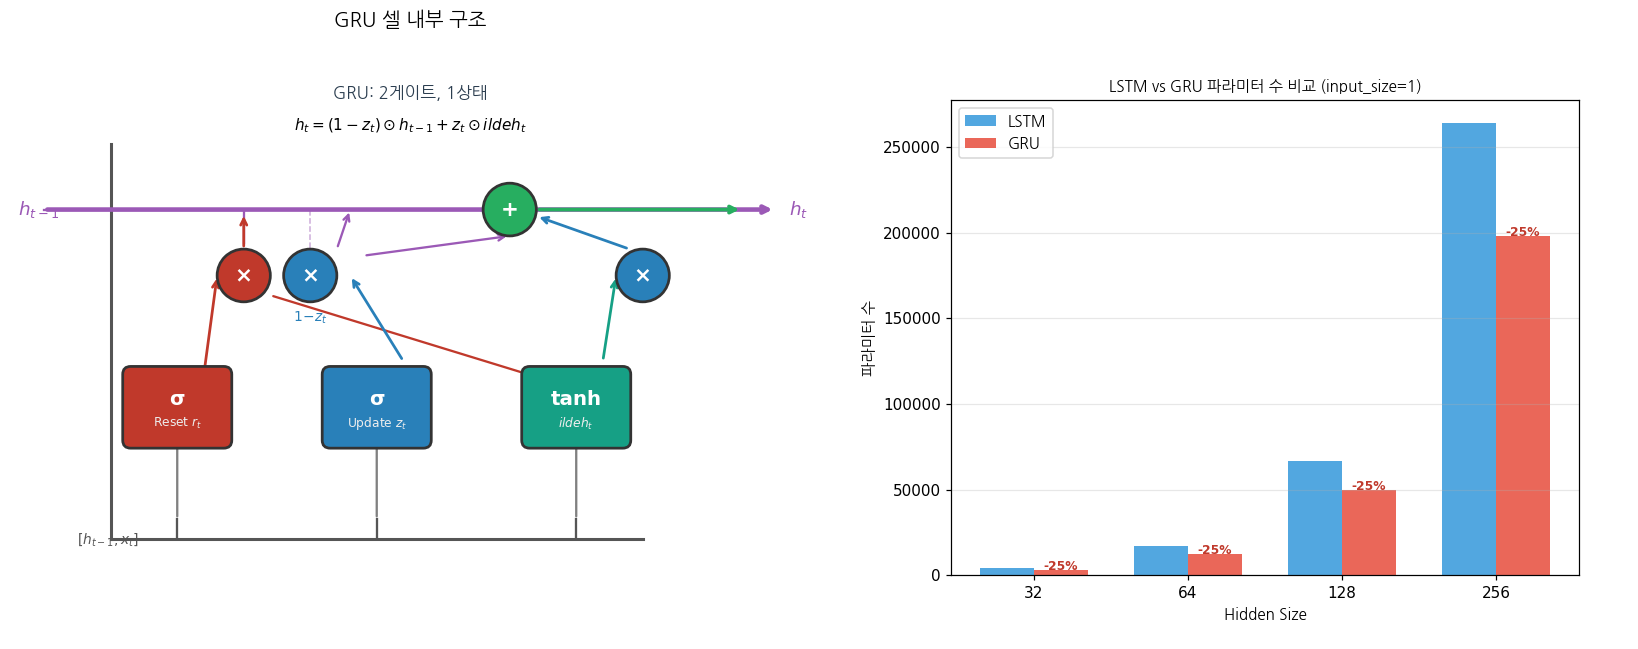

In [24]:
# ── GRU vs LSTM 구조 시각화 ──
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── [왼쪽] GRU 구조 ──
ax = axes[0]
ax.set_xlim(0, 12); ax.set_ylim(0, 9); ax.axis('off')
ax.set_title("GRU 셀 내부 구조", fontproperties=font_prop, fontsize=13, pad=12)

# h_{t-1} 흐름 라인
ax.annotate('', xy=(11.5, 6.5), xytext=(0.5, 6.5),
            arrowprops=dict(arrowstyle='->', color='#9b59b6', lw=3))
ax.text(0.1, 6.5, '$h_{t-1}$', fontsize=12, color='#9b59b6', fontweight='bold', va='center')
ax.text(11.7, 6.5, '$h_t$', fontsize=12, color='#9b59b6', fontweight='bold', va='center')

# 게이트 (Reset, Update)
def gru_gate(ax, cx, cy, color, sym, name):
    r = FancyBboxPatch((cx-0.7, cy-0.5), 1.4, 1.0,
                        boxstyle="round,pad=0.12", fc=color, ec='#333', lw=1.8, zorder=4)
    ax.add_patch(r)
    ax.text(cx, cy+0.12, sym, ha='center', va='center', fontsize=13, fontweight='bold', color='white', zorder=5)
    ax.text(cx, cy-0.25, name, ha='center', va='center', fontsize=8, color='#eee', zorder=5)

def gru_op(ax, cx, cy, color, sym):
    c = plt.Circle((cx, cy), 0.4, color=color, ec='#333', lw=1.8, zorder=4)
    ax.add_patch(c)
    ax.text(cx, cy, sym, ha='center', va='center', fontsize=14, fontweight='bold', color='white', zorder=5)

gru_gate(ax, 2.5, 3.5, '#c0392b', 'σ', 'Reset $r_t$')
gru_gate(ax, 5.5, 3.5, '#2980b9', 'σ', 'Update $z_t$')
gru_gate(ax, 8.5, 3.5, '#16a085', 'tanh', '$\tilde{h}_t$')

# Reset: r_t ⊙ h_{t-1}
gru_op(ax, 3.5, 5.5, '#c0392b', '×')
gru_op(ax, 7.5, 6.5, '#27ae60', '+')   # (1-z)*h + z*h_tilde
gru_op(ax, 9.5, 5.5, '#2980b9', '×')   # z * h_tilde
gru_op(ax, 4.5, 5.5, '#2980b9', '×')   # (1-z) * h_{t-1}

# 1-z 계산
ax.text(4.5, 4.8, '$1\!-\!z_t$', fontsize=9, ha='center', color='#2980b9')

# 화살표들
for x_gate in [2.5, 5.5, 8.5]:
    ax.annotate('', xy=(x_gate, 2.5+0.7), xytext=(x_gate, 1.8),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

ax.plot([1.5, 1.5], [1.5, 7.5], color='#555', lw=2, zorder=2)
ax.plot([1.5, 9.5], [1.5, 1.5], color='#555', lw=2, zorder=2)
ax.text(1.0, 1.5, '$[h_{t-1},x_t]$', fontsize=9, color='#555', va='center')
for x in [2.5, 5.5, 8.5]:
    ax.plot([x, x], [1.5, 1.8], color='#555', lw=1.5, zorder=2)

ax.annotate('', xy=(3.1, 5.5), xytext=(2.9, 4.0),
            arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.8))
ax.annotate('', xy=(3.5, 6.5-0.05), xytext=(3.5, 5.9),
            arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.8))
ax.plot([0.5, 3.5], [6.5, 6.5], color='#9b59b6', lw=1.5)
ax.plot([3.5, 3.5], [6.5, 6.0], color='#9b59b6', lw=1.5)
ax.annotate('', xy=(8.1, 3.9), xytext=(3.9, 5.2),
            arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.5))
ax.annotate('', xy=(9.1, 5.5), xytext=(8.9, 4.2),
            arrowprops=dict(arrowstyle='->', color='#16a085', lw=1.8))
ax.annotate('', xy=(7.9, 6.4), xytext=(9.3, 5.9),
            arrowprops=dict(arrowstyle='->', color='#2980b9', lw=1.8))
ax.annotate('', xy=(5.1, 5.5), xytext=(5.9, 4.2),
            arrowprops=dict(arrowstyle='->', color='#2980b9', lw=1.8))
ax.plot([0.5, 4.5], [6.5, 6.5], color='#9b59b6', lw=1, ls='--', alpha=0.5)
ax.plot([4.5, 4.5], [6.5, 5.9], color='#9b59b6', lw=1, ls='--', alpha=0.5)
ax.annotate('', xy=(5.1, 6.5), xytext=(4.9, 5.9),
            arrowprops=dict(arrowstyle='->', color='#9b59b6', lw=1.5))
ax.annotate('', xy=(7.5, 6.1), xytext=(5.3, 5.8),
            arrowprops=dict(arrowstyle='->', color='#9b59b6', lw=1.5))
ax.annotate('', xy=(11.0, 6.5), xytext=(7.9, 6.5),
            arrowprops=dict(arrowstyle='->', color='#27ae60', lw=2.5))

ax.text(6, 8.2, 'GRU: 2게이트, 1상태', ha='center', fontsize=11,
        color='#2c3e50', fontproperties=font_prop, fontweight='bold')
ax.text(6, 7.7, '$h_t = (1-z_t)\odot h_{t-1} + z_t \odot \tilde{h}_t$', ha='center', fontsize=10)

# ── [오른쪽] LSTM vs GRU 파라미터 비교 ──
ax2 = axes[1]
ax2.axis('off')

sizes_h = [32, 64, 128, 256]
lstm_params = [4*(h*h + 1*h + h) for h in sizes_h]
gru_params  = [3*(h*h + 1*h + h) for h in sizes_h]
x_pos = np.arange(len(sizes_h))
width = 0.35

ax_bar = fig.add_axes([0.58, 0.12, 0.38, 0.72])
bars_l = ax_bar.bar(x_pos - width/2, lstm_params, width, label='LSTM', color='#3498db', alpha=0.85)
bars_g = ax_bar.bar(x_pos + width/2, gru_params,  width, label='GRU',  color='#e74c3c', alpha=0.85)
ax_bar.set_xlabel("Hidden Size", fontproperties=font_prop)
ax_bar.set_ylabel("파라미터 수", fontproperties=font_prop)
ax_bar.set_title("LSTM vs GRU 파라미터 수 비교 (input_size=1)", fontproperties=font_prop)
ax_bar.set_xticks(x_pos); ax_bar.set_xticklabels([str(h) for h in sizes_h])
ax_bar.legend(prop=font_prop)
ax_bar.grid(axis='y', alpha=0.3)
for bl, bg in zip(bars_l, bars_g):
    ratio = (1 - bg.get_height()/bl.get_height())*100
    ax_bar.text(bg.get_x()+bg.get_width()/2, bg.get_height()+50,
                f'-{ratio:.0f}%', ha='center', fontsize=8, color='#c0392b', fontweight='bold')

plt.tight_layout(); plt.show()


## 3-2. GRU NumPy 구현 및 게이트 분석

### Update Gate의 이중 역할

$$h_t = \underbrace{(1 - z_t)}_{\text{이전 기억 유지}} \odot h_{t-1} + \underbrace{z_t}_{\text{새 정보 반영}} \odot \tilde{h}_t$$

- $z_t \approx 0$: 이전 상태 $h_{t-1}$를 그대로 유지 (Forget + Input 통합)
- $z_t \approx 1$: 새 후보 $\tilde{h}_t$로 완전 교체

### Reset Gate의 역할

$$\tilde{h}_t = \tanh(W[r_t \odot h_{t-1},\; x_t])$$

- $r_t \approx 0$: 과거 기억 무시 → 완전히 새로운 정보만 사용
- $r_t \approx 1$: 과거 기억 활용 → LSTM의 메모리 역할


In [25]:
class GRUNumpy:
    """
    GRU — NumPy 완전 구현

    z_t = σ(Wz @ [x_t, h_{t-1}] + bz)  # Update gate
    r_t = σ(Wr @ [x_t, h_{t-1}] + br)  # Reset gate
    h̃_t = tanh(Wh @ [x_t, r_t⊙h_{t-1}] + bh)  # Candidate
    h_t = (1-z_t)⊙h_{t-1} + z_t⊙h̃_t
    """
    def __init__(self, input_size, hidden_size, output_size, lr=0.01):
        self.I = input_size
        self.H = hidden_size
        self.O = output_size
        self.lr = lr
        D = input_size + hidden_size
        s = lambda n: np.sqrt(2/n)
        # 3 게이트 각각의 가중치 행렬
        self.Wz  = np.random.randn(hidden_size, D) * s(D)  # Update gate
        self.Wr  = np.random.randn(hidden_size, D) * s(D)  # Reset gate
        self.Wh  = np.random.randn(hidden_size, D) * s(D)  # Candidate
        self.bz  = np.zeros((hidden_size, 1))
        self.br  = np.zeros((hidden_size, 1))
        self.bh  = np.zeros((hidden_size, 1))
        self.Why = np.random.randn(output_size, hidden_size) * s(hidden_size)
        self.by  = np.zeros((output_size, 1))

    def forward(self, xs, h0=None):
        h = h0 if h0 is not None else np.zeros((self.H, 1))
        hs, ys, cache = [h], [], []
        for x in xs:
            combined  = np.vstack([x, h])
            z = sigmoid(self.Wz @ combined + self.bz)      # Update
            r = sigmoid(self.Wr @ combined + self.br)      # Reset
            combined_r = np.vstack([x, r * h])
            h_tilde = np.tanh(self.Wh @ combined_r + self.bh)  # Candidate
            h_new   = (1 - z) * h + z * h_tilde           # 업데이트
            y       = self.Why @ h_new + self.by
            cache.append((x, h, z, r, h_tilde, combined, combined_r))
            h = h_new
            hs.append(h); ys.append(y)
        return hs, ys, cache

    def bptt(self, xs, ys_true, h0=None):
        T = len(xs)
        hs, ys_pred, cache = self.forward(xs, h0)

        dWz=np.zeros_like(self.Wz); dWr=np.zeros_like(self.Wr)
        dWh=np.zeros_like(self.Wh)
        dbz=np.zeros_like(self.bz); dbr=np.zeros_like(self.br)
        dbh=np.zeros_like(self.bh)
        dWhy=np.zeros_like(self.Why); dby=np.zeros_like(self.by)
        dh_next = np.zeros((self.H, 1))

        total_loss = 0.0
        for t in reversed(range(T)):
            x, h_prev, z, r, h_tilde, combined, combined_r = cache[t]
            h_curr = hs[t+1]
            dy     = ys_pred[t] - ys_true[t]
            total_loss += float(np.sum(dy**2))
            dWhy += dy @ h_curr.T; dby += dy

            dh = self.Why.T @ dy + dh_next
            # h_t = (1-z)*h_{t-1} + z*h_tilde
            dh_tilde = dh * z
            dz       = dh * (h_tilde - h_prev)
            dh_prev  = dh * (1 - z)

            # h_tilde = tanh(Wh @ combined_r)
            dh_tilde_raw = dh_tilde * dtanh(h_tilde)
            dWh += dh_tilde_raw @ combined_r.T; dbh += dh_tilde_raw
            d_combined_r = self.Wh.T @ dh_tilde_raw
            dx_part  = d_combined_r[:self.I]
            drh_part = d_combined_r[self.I:]
            dr       = drh_part * h_prev
            dh_prev += drh_part * r

            # z, r gates
            dz_raw = dz * dsigmoid(z); dr_raw = dr * dsigmoid(r)
            dWz += dz_raw @ combined.T; dbz += dz_raw
            dWr += dr_raw @ combined.T; dbr += dr_raw
            d_combined_z = self.Wz.T @ dz_raw
            d_combined_r2= self.Wr.T @ dr_raw
            dh_prev += d_combined_z[self.I:] + d_combined_r2[self.I:]
            dh_next  = dh_prev

        for grad in [dWz,dWr,dWh,dWhy,dbz,dbr,dbh,dby]:
            np.clip(grad, -5, 5, out=grad)

        self.Wz -= self.lr*dWz; self.Wr -= self.lr*dWr
        self.Wh -= self.lr*dWh; self.Why-= self.lr*dWhy
        self.bz -= self.lr*dbz; self.br -= self.lr*dbr
        self.bh -= self.lr*dbh; self.by -= self.lr*dby

        return total_loss / T

    def count_params(self):
        return (self.Wz.size+self.Wr.size+self.Wh.size
                +self.bz.size+self.br.size+self.bh.size
                +self.Why.size+self.by.size)


I, H, O = 1, 16, 1
gru = GRUNumpy(I, H, O)
print(f"GRU 파라미터 수: {gru.count_params():,}개")
print(f"LSTM 파라미터 수: {LSTMNumpy(I,H,O).count_params():,}개")
print(f"RNN  파라미터 수: {VanillaRNNNumpy(I,H,O).count_params():,}개")
print(f"\nGRU는 LSTM 대비 {(1 - gru.count_params()/LSTMNumpy(I,H,O).count_params())*100:.1f}% 파라미터 절약")


GRU 파라미터 수: 881개
LSTM 파라미터 수: 1,169개
RNN  파라미터 수: 305개

GRU는 LSTM 대비 24.6% 파라미터 절약


■ 3모델 비교 훈련 (사인파 예측)...


  GRU  최종: 0.000429
  LSTM 최종: 0.000506
  RNN  최종: 0.000563


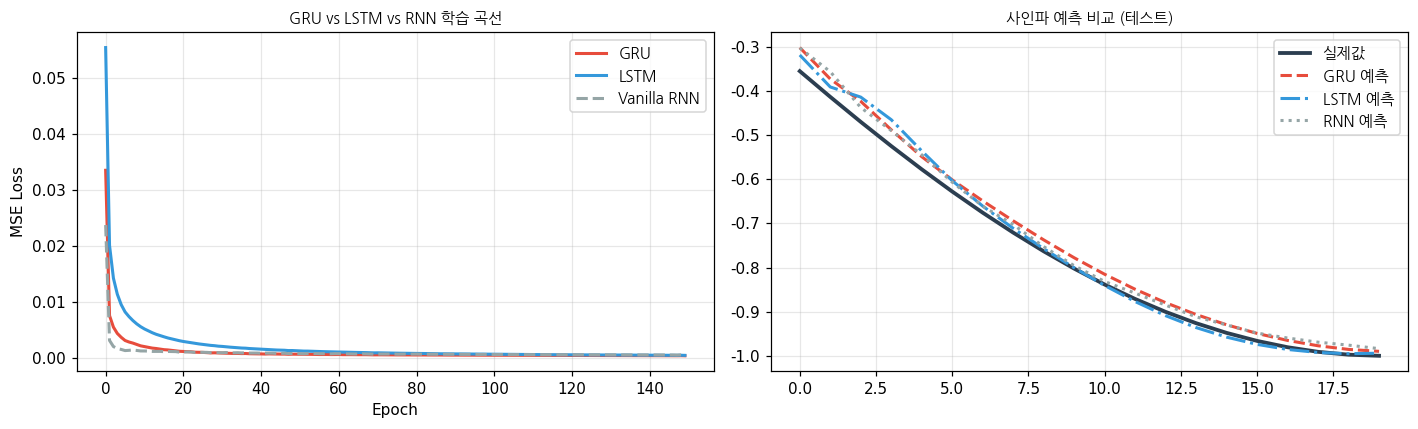

In [28]:
# ── 3모델 동시 비교 훈련 ──
print("■ 3모델 비교 훈련 (사인파 예측)...")

gru_sin  = GRUNumpy(1, 32, 1,  lr=0.005)
lstm_sin3= LSTMNumpy(1, 32, 1, lr=0.005)
rnn_sin3 = VanillaRNNNumpy(1, 32, 1, lr=0.005)

gru_losses, lstm_losses3, rnn_losses3 = [], [], []
EPOCHS = 150

for ep in range(EPOCHS):
    g_loss=l_loss=r_loss=0
    indices = list(range(len(X_tr))); random.shuffle(indices)
    for idx in indices:
        g_loss += gru_sin.bptt(X_tr[idx], Y_tr[idx])
        l_loss += lstm_sin3.bptt(X_tr[idx], Y_tr[idx])
        r_loss += rnn_sin3.bptt(X_tr[idx], Y_tr[idx])
    gru_losses.append(g_loss/len(X_tr))
    lstm_losses3.append(l_loss/len(X_tr))
    rnn_losses3.append(r_loss/len(X_tr))

print(f"  GRU  최종: {gru_losses[-1]:.6f}")
print(f"  LSTM 최종: {lstm_losses3[-1]:.6f}")
print(f"  RNN  최종: {rnn_losses3[-1]:.6f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(gru_losses,   color='#e74c3c', lw=2,   label='GRU')
axes[0].plot(lstm_losses3, color='#3498db', lw=2,   label='LSTM')
axes[0].plot(rnn_losses3,  color='#95a5a6', lw=2, ls='--', label='Vanilla RNN')
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE Loss")
axes[0].set_title("GRU vs LSTM vs RNN 학습 곡선", fontproperties=font_prop)
axes[0].legend(prop=font_prop); axes[0].grid(alpha=0.3)

gru_pred  = predict_seq(gru_sin,  X_te[10])
lstm_pred3= predict_seq(lstm_sin3,X_te[10])
rnn_pred3 = predict_seq(rnn_sin3, X_te[10])
true10    = [float(y) for y in Y_te[10]]

axes[1].plot(true10,     label='실제값',       color='#2c3e50', lw=2.5)
axes[1].plot(gru_pred,   label='GRU 예측',     color='#e74c3c', lw=2, ls='--')
axes[1].plot(lstm_pred3, label='LSTM 예측',    color='#3498db', lw=2, ls='-.')
axes[1].plot(rnn_pred3,  label='RNN 예측',     color='#95a5a6', lw=2, ls=':')
axes[1].set_title("사인파 예측 비교 (테스트)", fontproperties=font_prop)
axes[1].legend(prop=font_prop); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()


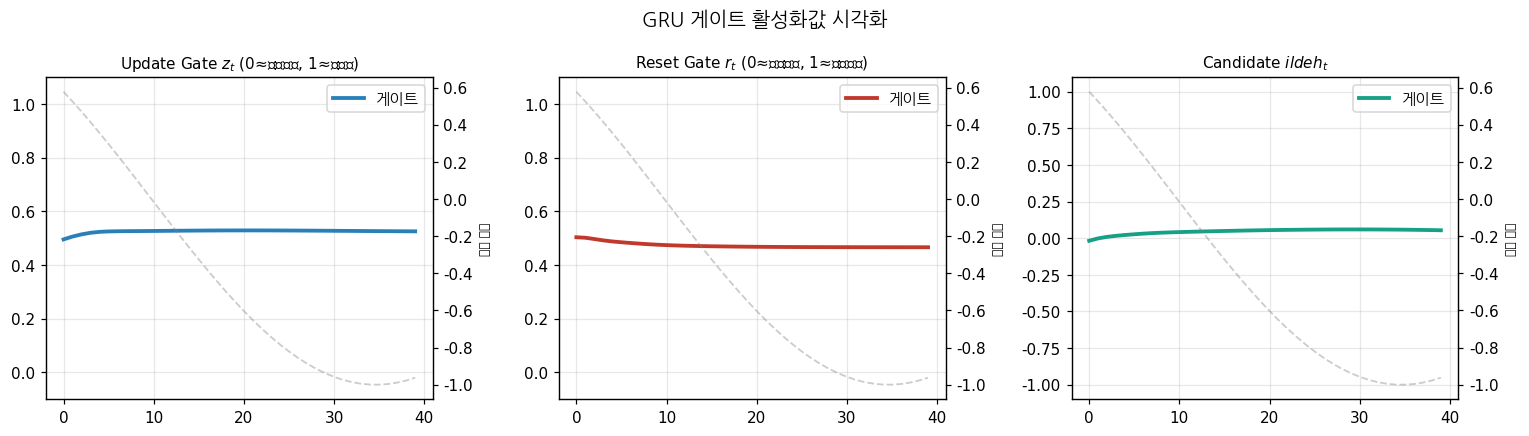

In [29]:
# ── GRU 게이트 활성화 시각화 ──
sample_xs2 = [np.array([[v]]) for v in signal[40:80]]
_, _, gru_cache = gru_sin.forward(sample_xs2)

z_vals = np.array([float(c[2].mean()) for c in gru_cache])  # update
r_vals = np.array([float(c[3].mean()) for c in gru_cache])  # reset
h_vals = np.array([float(c[4].mean()) for c in gru_cache])  # candidate
in_sig = signal[40:80]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
data_list = [
    (z_vals, 'Update Gate $z_t$ (0≈이전유지, 1≈새정보)', '#2980b9'),
    (r_vals, 'Reset Gate $r_t$ (0≈과거무시, 1≈과거활용)', '#c0392b'),
    (h_vals, 'Candidate $\tilde{h}_t$', '#16a085'),
]
for ax, (vals, title, color) in zip(axes, data_list):
    ax.plot(vals, color=color, lw=2.5, label='게이트')
    ax2_ = ax.twinx()
    ax2_.plot(in_sig, color='gray', lw=1.2, alpha=0.4, ls='--', label='입력')
    ax2_.set_ylabel("입력 신호", fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.set_ylim(-0.1, 1.1) if '\tilde' not in title else ax.set_ylim(-1.1, 1.1)
    ax.grid(alpha=0.3)
    ax.legend(prop=font_prop, fontsize=8)

plt.suptitle("GRU 게이트 활성화값 시각화", fontproperties=font_prop, fontsize=13)
plt.tight_layout(); plt.show()


---
# PART 4. 종합 비교 분석

## 4-1. PyTorch GRU 구현 및 문자 언어 모델


In [30]:
# ── PyTorch로 3모델 동시 구현 ──
class CharRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, model_type='lstm', num_layers=2):
        super().__init__()
        self.model_type  = model_type
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        self.embed = nn.Embedding(vocab_size, embed_dim)

        RNN_MAP = {'rnn': nn.RNN, 'lstm': nn.LSTM, 'gru': nn.GRU}
        self.rnn = RNN_MAP[model_type](
            embed_dim, hidden_size, num_layers,
            batch_first=True,
            dropout=0.3 if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        emb    = self.embed(x)
        out, h = self.rnn(emb, hidden)
        return self.fc(out), h

    def init_hidden(self, B, dev):
        h = torch.zeros(self.num_layers, B, self.hidden_size).to(dev)
        if self.model_type == 'lstm':
            return (h, torch.zeros_like(h))
        return h

    def count_params(self):
        return sum(p.numel() for p in self.parameters())


models_pt = {
    'RNN' : CharRNN(V, 32, 128, 'rnn',  2).to(device),
    'LSTM': CharRNN(V, 32, 128, 'lstm', 2).to(device),
    'GRU' : CharRNN(V, 32, 128, 'gru',  2).to(device),
}

print("■ PyTorch 모델 파라미터 수 비교 (H=128, L=2, V={V}, embed=32):")
for name, m in models_pt.items():
    print(f"  {name:4s}: {m.count_params():,}개")

optimizers = {k: optim.Adam(m.parameters(), lr=3e-3) for k, m in models_pt.items()}
schedulers = {k: optim.lr_scheduler.StepLR(opt, 30, 0.8) for k, opt in optimizers.items()}


■ PyTorch 모델 파라미터 수 비교 (H=128, L=2, V={V}, embed=32):
  RNN : 57,624개
  LSTM: 218,904개
  GRU : 165,144개


In [31]:
# ── 동시 훈련 ──
EPOCHS_PT = 200
all_losses = {k: [] for k in models_pt}
train_times = {}

print("■ 훈련 시작...")
for name, model in models_pt.items():
    model.train()
    t0 = time.time()
    for ep in range(EPOCHS_PT):
        ep_loss, steps = 0, 0
        for xs, ys in make_batches(text, SEQ_LEN, 16):
            optimizers[name].zero_grad()
            hidden  = model.init_hidden(xs.size(0), device)
            logits, _ = model(xs, hidden)
            loss = criterion(logits.reshape(-1, V), ys.reshape(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5)
            optimizers[name].step()
            ep_loss += loss.item(); steps += 1
        schedulers[name].step()
        all_losses[name].append(ep_loss / max(steps,1))
    elapsed = time.time() - t0
    train_times[name] = elapsed
    print(f"  {name:4s} 완료  | 최종 loss={all_losses[name][-1]:.4f} | 시간={elapsed:.1f}s")


■ 훈련 시작...
  RNN  완료  | 최종 loss=0.0311 | 시간=5.0s
  LSTM 완료  | 최종 loss=0.0430 | 시간=7.0s
  GRU  완료  | 최종 loss=0.0318 | 시간=10.7s


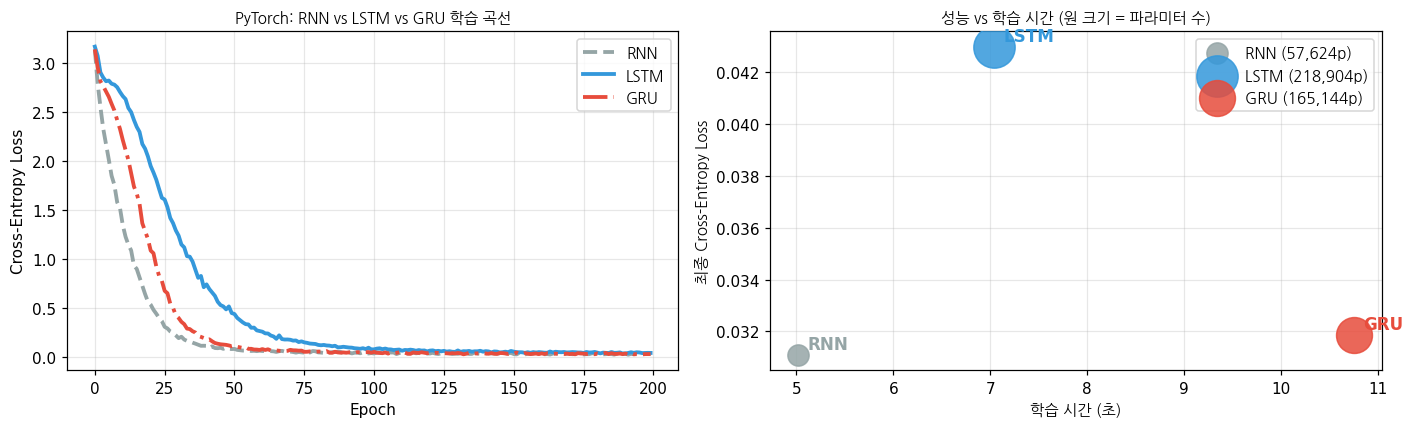

In [32]:
# ── 결과 시각화 ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors_m = {'RNN':'#95a5a6','LSTM':'#3498db','GRU':'#e74c3c'}
styles   = {'RNN':'--','LSTM':'-','GRU':'-.'}

for name, losses in all_losses.items():
    axes[0].plot(losses, label=name, color=colors_m[name],
                 lw=2.5, ls=styles[name])
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].set_title("PyTorch: RNN vs LSTM vs GRU 학습 곡선", fontproperties=font_prop)
axes[0].legend(prop=font_prop); axes[0].grid(alpha=0.3)

# 최종 성능 vs 학습 시간 산포도
names = list(models_pt.keys())
final_losses = [all_losses[n][-1] for n in names]
times_list   = [train_times[n] for n in names]
params_list  = [models_pt[n].count_params() for n in names]

for n, fl, t, p in zip(names, final_losses, times_list, params_list):
    axes[1].scatter(t, fl, s=p/300, color=colors_m[n], alpha=0.85, zorder=3,
                    label=f"{n} ({p:,}p)")
    axes[1].annotate(n, (t, fl), textcoords="offset points",
                     xytext=(6, 4), fontsize=11, color=colors_m[n], fontweight='bold')

axes[1].set_xlabel("학습 시간 (초)", fontproperties=font_prop)
axes[1].set_ylabel("최종 Cross-Entropy Loss", fontproperties=font_prop)
axes[1].set_title("성능 vs 학습 시간 (원 크기 = 파라미터 수)", fontproperties=font_prop)
axes[1].legend(prop=font_prop, fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()


In [33]:
# ── 텍스트 생성 비교 ──
def generate_text(model, seed, length=60, temperature=0.8):
    model.eval()
    ids = encode(seed)
    x   = torch.LongTensor([ids]).to(device)
    hidden = model.init_hidden(1, device)
    result = seed
    with torch.no_grad():
        for _ in range(length):
            logits, hidden = model(x, hidden)
            logits = logits[:,-1,:] / temperature
            probs  = F.softmax(logits, dim=-1)
            nxt    = torch.multinomial(probs, 1).item()
            result += idx2char[nxt]
            x = torch.LongTensor([[nxt]]).to(device)
    return result

print("■ 텍스트 생성 비교 (seed='deep learning', T=0.7):")
for name, model in models_pt.items():
    gen = generate_text(model, "deep learning", length=60, temperature=0.7)
    print(f"  {name:4s}: {gen}")


■ 텍스트 생성 비교 (seed='deep learning', T=0.7):
  RNN : deep learning is a subset of machine learning neural networks have multip
  LSTM: deep learning is a subset of machine learning neurlent neural networks pr
  GRU : deep learning is a subset of machine learning neural networks process seq


## 4-2. 종합 비교: Vanilla RNN · LSTM · GRU

### 구조 비교

| | Vanilla RNN | LSTM | GRU |
|---|:---:|:---:|:---:|
| **논문** | Elman (1990) | Hochreiter (1997) | Cho (2014) |
| **상태 수** | 1 ($h_t$) | 2 ($h_t$, $c_t$) | 1 ($h_t$) |
| **게이트 수** | 0 | 4 (f, i, g, o) | 2 (z, r) |
| **파라미터** | $H^2 + IH + H$ | $4(H^2 + IH + H)$ | $3(H^2 + IH + H)$ |
| **기울기 소실** | ❌ 심각 | ✅ CEC로 해결 | ✅ Update gate로 해결 |
| **장기 의존성** | ❌ | ✅ 우수 | ✅ 우수 |
| **셀 상태 분리** | ❌ | ✅ ($c_t$ 별도) | ❌ ($h_t$에 통합) |
| **계산 비용** | 낮음 | 높음 | 중간 |
| **소규모 데이터** | ⚠️ | ✅ | ✅✅ |
| **대규모 데이터** | ❌ | ✅✅ | ✅ |

### GRU vs LSTM 핵심 차이 요약

| 관점 | LSTM 우위 | GRU 우위 |
|------|----------|---------|
| **표현력** | 셀 상태($c_t$)로 장기/단기 분리 | - |
| **파라미터 효율** | - | 25% 적은 파라미터 |
| **학습 속도** | - | 빠름 (행렬 연산 1회 적음) |
| **소규모 데이터** | - | 과적합 위험 낮음 |
| **장기 시퀀스** | Forget gate 세밀 조절 가능 | - |
| **실용성** | 범용적 (더 많은 연구) | 빠른 프로토타입 |

```

---
*참고 논문*
- Hochreiter & Schmidhuber (1997) — *Long Short-Term Memory*, Neural Computation
- Cho et al. (2014) — *Learning Phrase Representations using RNN Encoder-Decoder*, EMNLP
- Chung et al. (2014) — *Empirical Evaluation of Gated Recurrent Neural Networks*, NIPS Workshop
